In [1]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.tile.nearest import Tile2SymbNearest

from tests.experimental.grayscale.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/Inconsolata-Regular.ttf"
FONT_SIZE = 14
MAX_WIDTH = 80
MAX_HEIGHT = 24
IMG_SET_PATH = "../../../../imgs/BSDS500"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:5]]


def make_converter(params: Params):
    return Tile2SymbNearest(
        symbols=SYMBOLS,
        font=ImageFont.truetype(params.font_path, params.font_size),
        **params.converter_args)

Min: 0.1115 | Max: 0.1844 | Mean: 0.1439 | Std: 0.0265
Min: 0.1148 | Max: 0.2021 | Mean: 0.1542 | Std: 0.0302
Min: 0.1314 | Max: 0.2590 | Mean: 0.1918 | Std: 0.0454
Min: 0.1323 | Max: 0.2484 | Mean: 0.1857 | Std: 0.0423


C:\Users\wojte\AppData\Local\Temp\ipykernel_2468\1862186084.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


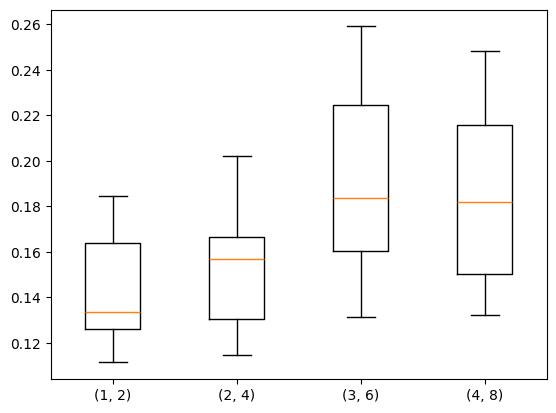

In [2]:
# val_wh

params_space = [
    (w, w * 2) for w in range(1, 5, 1)
]

params_space = list(
    map(lambda val_wh: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={'val_wh': val_wh},
        preprocess_args={}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['val_wh'] for param in params_space])
plt.show()

Min: 0.0820 | Max: 0.1439 | Mean: 0.1111 | Std: 0.0245
Min: 0.1147 | Max: 0.2341 | Mean: 0.1665 | Std: 0.0467
Min: 0.1644 | Max: 0.2841 | Mean: 0.2298 | Std: 0.0400
Min: 0.1850 | Max: 0.2994 | Mean: 0.2576 | Std: 0.0420
Min: 0.1938 | Max: 0.3041 | Mean: 0.2656 | Std: 0.0414


C:\Users\wojte\AppData\Local\Temp\ipykernel_2468\549677722.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


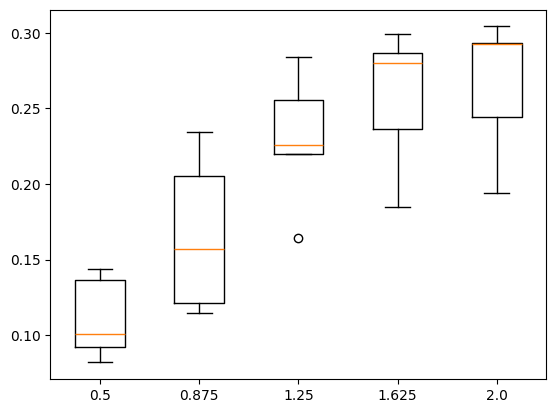

In [3]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: Params(
        max_width=MAX_WIDTH,
        max_height=MAX_HEIGHT,
        font_path=FONT_PATH,
        font_size=FONT_SIZE,
        converter_args={},
        preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

In [7]:
import math
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery


converter = Tile2SymbNearest(symbols=SYMBOLS,
                             font=ImageFont.truetype(FONT_PATH, FONT_SIZE))

results = []
for img_path in IMG_PATHS:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    win_width = math.ceil(img.size[0] / MAX_WIDTH)
    win_height = math.ceil(img.size[1] / MAX_HEIGHT)
    results.append(converter.process_image(img, (win_width, win_height)))

print_gallery(results, 1)

---------------------------------------------------------------------------
 | sssssssjj_______________jjj_jjjj,jjj^??^^^^^<<<<>>'```?W??>><<r~~ `~  | 
 | ^<<?5%%%%%WWWWWWWWWWgBB%%%WWWBWWWW=%aaWWWWWWWWWWWWW%ggggasssssass= =  | 
 |         ``   ```` `??Wgg5WWWWWWW<=~~ ` ``^???<W%8W><??^`^^``<<>>=-    | 
 |                   <5<`??``-               ~~.                         | 
 | ggggggggggggggggggggggggggjjj____,,,,,,,,,_,    `                     | 
 | BBgQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQBBBBBQQQQQQggggggggggggggggj | 
 | BBBQBQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQBBBBBBBBE | 
 | QBBQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQBBBBBBF | 
 | BBBBBQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQgQQQQQQQQQQQQQQQQQQgBBF | 
 | BQBQQQQQQQQQQQQQQQQQQBBQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQQBBBBBBF | 
 | BBQQQQQQQQQQQQQQQBR?~`````^??WWBQQQQQQQQQQQQQQQQQQQQQQQQQQQQBBQBBQBgE | 
 | gBQQBQQQQQQQQQQQQE-  ` `````  `~/NQQQQQQQQQQQQQQQQQQQQQQQQQQQQBQBBBBF | 
 | BBBQQQQQQ